# 2026-03-18 LSH 분석 시작

새 분석 노트북입니다. 우선 데이터 로드와 기본 확인부터 진행합니다.


## 1. 환경 설정


In [34]:
import pandas as pd
import numpy as np
import warnings
import holidays
import matplotlib.pyplot as plt
import koreanize_matplotlib

warnings.filterwarnings('ignore')


## 2. 데이터 로드


In [35]:
DATA_2024_PATH = '../../Data/Zero/2024_data.csv'
DATA_2025_PATH = '../../Data/Zero/2025_data.csv'
STATION_META_PATH = '../../Data/은평구_스테이션_군집화_1차_자전거댓수_추가.csv'

df2024 = pd.read_csv(DATA_2024_PATH)
df2025 = pd.read_csv(DATA_2025_PATH)
station_meta = pd.read_csv(STATION_META_PATH, encoding='utf-8-sig')

station_meta = station_meta[[
    '대여소_ID', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR'
]].rename(columns={'대여소_ID': '시작_대여소_ID'})

for col in ['위도', '경도', 'cluster_12_custom', 'LCD', 'QR']:
    station_meta[col] = pd.to_numeric(station_meta[col], errors='coerce')

df = pd.concat([df2024, df2025], axis=0, ignore_index=True)
kr = holidays.KR()


## 3. 데이터 기본 확인


In [36]:
print('df2024 shape:', df2024.shape)
print('df2025 shape:', df2025.shape)
print('df total shape:', df.shape)
print('station_meta shape:', station_meta.shape)

display(df.head())
display(station_meta.head())


df2024 shape: (187117, 13)
df2025 shape: (160165, 13)
df total shape: (347282, 13)
station_meta shape: (98, 6)


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량
0,2024-01-01,0,출발시간,ST-454,ST-1331,1.0,6900,11170.0,-2.7,92,28.49784,0.0,0.0
1,2024-01-01,0,출발시간,ST-454,ST-349,1.0,1560,4473.0,-2.7,92,28.49784,0.0,0.0
2,2024-01-01,0,출발시간,ST-454,ST-1025,1.0,720,1960.0,-2.7,92,28.49784,0.0,0.0
3,2024-01-01,0,출발시간,ST-479,ST-454,2.0,1200,2953.0,-2.7,92,28.49784,0.0,0.0
4,2024-01-01,0,출발시간,ST-1035,ST-3058,1.0,840,1821.0,-2.7,92,28.49784,0.0,0.0


,시작_대여소_ID,위도,경도,cluster_12_custom,LCD,QR
0,ST-453,37.636234,126.918999,1,11.0,10.0
1,ST-1483,37.639259,126.918907,1,10.0,0.0
2,ST-1481,37.638252,126.919456,1,15.0,0.0
3,ST-1329,37.642609,126.921478,1,10.0,0.0
4,ST-2244,37.643509,126.924103,1,0.0,10.0


## 4. 기본 정보 점검


In [37]:
basic_info_df = pd.DataFrame({
    '항목': [
        '전체 행 수',
        '2024 행 수',
        '2025 행 수',
        '시작 대여소 수',
        '종료 대여소 수',
        '전체_건수 결측 수',
        '온도 결측 수',
        '습도 결측 수',
        '강수량 결측 수',
        '적설량 결측 수'
    ],
    '값': [
        len(df),
        len(df2024),
        len(df2025),
        df['시작_대여소_ID'].nunique(),
        df['종료_대여소_ID'].nunique(),
        int(df['전체_건수'].isna().sum()),
        int(df['온도'].isna().sum()),
        int(df['습도'].isna().sum()),
        int(df['강수량'].isna().sum()),
        int(df['적설량'].isna().sum())
    ]
})

display(basic_info_df)


,항목,값
0,전체 행 수,347282
1,2024 행 수,187117
2,2025 행 수,160165
3,시작 대여소 수,517
4,종료 대여소 수,550
5,전체_건수 결측 수,0
6,온도 결측 수,0
7,습도 결측 수,0
8,강수량 결측 수,0
9,적설량 결측 수,0


## 5. 변수 설계 원칙

- `불쾌지수`는 `온도`, `습도`의 파생 변수이므로 기본 모델 입력에서는 제외하는 방향으로 둡니다.
- 원본 데이터에서는 유지하되, 실제 피처셋 구성 시 중복 정보로 보고 우선 제외합니다.
- `전체_이용_분`, `전체_이용_거리`는 출퇴근 여부를 정의하는 탐색 지표로 먼저 봅니다.
- 출퇴근 여부는 `평일 여부 + 시간대 + 이용시간/거리 패턴`을 함께 보고 규칙을 정합니다.


## 6. 불쾌지수 제외용 기본 피처 후보


In [38]:
base_feature_candidates = [
    '시간대',
    '온도',
    '습도',
    '강수량',
    '적설량'
]

excluded_redundant_features = ['불쾌지수']

print('기본 피처 후보:', base_feature_candidates)
print('중복 가능성으로 우선 제외:', excluded_redundant_features)


기본 피처 후보: ['시간대', '온도', '습도', '강수량', '적설량']
중복 가능성으로 우선 제외: ['불쾌지수']


## 7. 출퇴근 여부 판단용 기초 집계


In [39]:
df_commute = df.copy()
df_commute['기준_날짜'] = pd.to_datetime(df_commute['기준_날짜'])
df_commute['weekday'] = df_commute['기준_날짜'].dt.dayofweek
df_commute['is_weekday'] = (df_commute['weekday'] < 5).astype(int)

hourly_trip_profile = df_commute.groupby(['is_weekday', '시간대'], as_index=False).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'mean',
    '전체_이용_거리': 'mean'
}).rename(columns={
    '전체_건수': 'hourly_total_count',
    '전체_이용_분': 'mean_use_min',
    '전체_이용_거리': 'mean_use_dist'
})

display(hourly_trip_profile.sort_values(['is_weekday', '시간대']))


,is_weekday,시간대,hourly_total_count,mean_use_min,mean_use_dist
0,0,0,4655.0,1062.179188,2521.309440
1,0,1,3368.0,1016.192893,2357.733886
2,0,2,2443.0,884.272340,2192.935209
3,0,3,1463.0,939.449153,2200.545519
4,0,4,818.0,1000.552764,2247.736709
5,0,5,816.0,923.180124,2212.184244
6,0,6,1034.0,1010.805501,2244.970060
7,0,7,2474.0,908.928277,2412.666529
8,0,8,3273.0,757.626483,1748.215848
9,0,9,3343.0,1166.925466,2345.993431


## 8. 1차 출퇴근 시간 후보 규칙

현재는 아래 규칙을 1차 후보로 둡니다.

- 평일(`is_weekday=1`) 기준
- 오전 `07~09시`, 오후 `17~19시`
- 이후 `전체_이용_분`, `전체_이용_거리` 평균이 실제로 다른지 보고 수정합니다.


In [40]:
df_commute['출퇴근시간_1차'] = (
    (df_commute['is_weekday'] == 1) &
    (df_commute['시간대'].isin([7, 8, 9, 17, 18, 19]))
).astype(int)

commute_candidate_summary = df_commute.groupby('출퇴근시간_1차', as_index=False).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'mean',
    '전체_이용_거리': 'mean'
}).rename(columns={
    '전체_건수': 'total_count',
    '전체_이용_분': 'mean_use_min',
    '전체_이용_거리': 'mean_use_dist'
})

display(commute_candidate_summary)


,출퇴근시간_1차,total_count,mean_use_min,mean_use_dist
0,0,257442.0,1250.330063,2510.107385
1,1,106411.0,1072.662253,2206.438004


## 9. 평일 시간대별 출퇴근 후보 확인


,is_weekday,시간대,hourly_total_count,mean_use_min,mean_use_dist
24,1,0,8879.0,915.161176,2202.479881
25,1,1,5891.0,947.230197,2253.368187
26,1,2,4054.0,980.148110,2220.745576
27,1,3,2652.0,961.231603,2203.622222
28,1,4,1407.0,1097.487217,2370.829646
29,1,5,2337.0,1004.285714,2498.212320
30,1,6,7904.0,695.993695,1592.617823
31,1,7,15525.0,665.830332,1755.625168
32,1,8,17001.0,680.866400,1578.026375
33,1,9,8476.0,982.779246,1927.739320


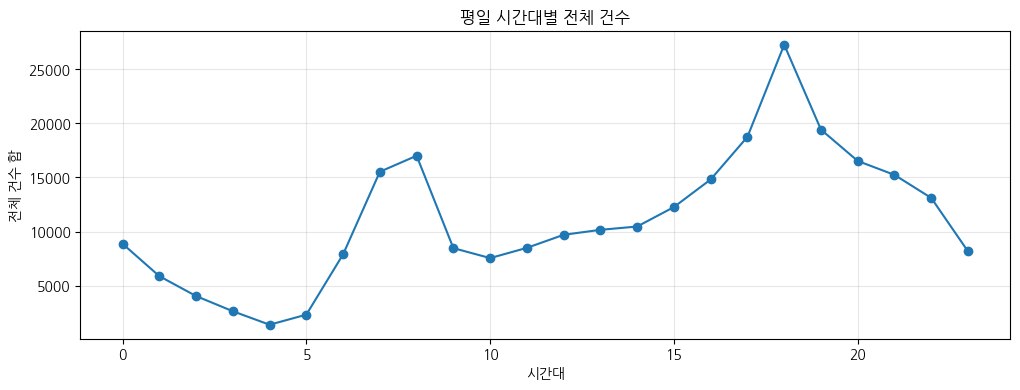

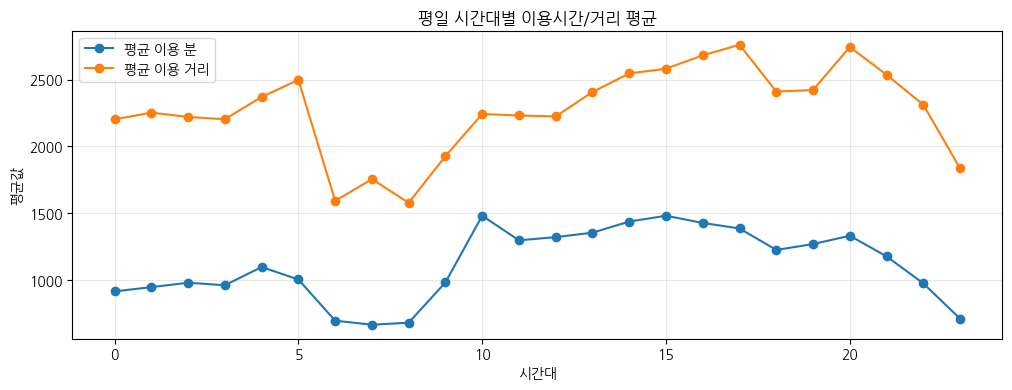

In [41]:
weekday_hour_profile = hourly_trip_profile[hourly_trip_profile['is_weekday'] == 1].copy()
weekday_hour_profile = weekday_hour_profile.sort_values('시간대')

display(weekday_hour_profile)

plt.figure(figsize=(12, 4))
plt.plot(weekday_hour_profile['시간대'], weekday_hour_profile['hourly_total_count'], marker='o')
plt.title('평일 시간대별 전체 건수')
plt.xlabel('시간대')
plt.ylabel('전체 건수 합')
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(weekday_hour_profile['시간대'], weekday_hour_profile['mean_use_min'], marker='o', label='평균 이용 분')
plt.plot(weekday_hour_profile['시간대'], weekday_hour_profile['mean_use_dist'], marker='o', label='평균 이용 거리')
plt.title('평일 시간대별 이용시간/거리 평균')
plt.xlabel('시간대')
plt.ylabel('평균값')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## 10. 출퇴근 시간 최종 규칙 초안

일단 아래 규칙으로 고정하고 진행합니다.

- 평일 기준
- 오전 `07~09시`, 오후 `17~19시`
- 이후 모델 성능이나 분포를 보고 범위를 줄이거나 넓힐 수 있습니다.


In [42]:
commute_hours_final = [7, 8, 9, 17, 18, 19]

df['기준_날짜'] = pd.to_datetime(df['기준_날짜'])
df['weekday'] = df['기준_날짜'].dt.dayofweek
df['is_weekday'] = (df['weekday'] < 5).astype(int)
df['출퇴근시간'] = (
    (df['is_weekday'] == 1) &
    (df['시간대'].isin(commute_hours_final))
).astype(int)

print('최종 출퇴근 시간대:', commute_hours_final)
display(df[['기준_날짜', '시간대', 'weekday', 'is_weekday', '출퇴근시간']].head())


최종 출퇴근 시간대: [7, 8, 9, 17, 18, 19]


,기준_날짜,시간대,weekday,is_weekday,출퇴근시간
0,2024-01-01,0,0,1,0
1,2024-01-01,0,0,1,0
2,2024-01-01,0,0,1,0
3,2024-01-01,0,0,1,0
4,2024-01-01,0,0,1,0


## 11. 분석 대상 스테이션 설정


In [43]:
target_station = ['ST-464', 'ST-481', 'ST-479']

print('분석 대상 스테이션:', target_station)
display(station_meta[station_meta['시작_대여소_ID'].isin(target_station)])


분석 대상 스테이션: ['ST-464', 'ST-481', 'ST-479']


,시작_대여소_ID,위도,경도,cluster_12_custom,LCD,QR
60,ST-479,37.604736,126.915337,8,19.0,0.0
61,ST-481,37.612484,126.914879,8,15.0,0.0
62,ST-464,37.607849,126.921326,8,13.0,0.0


## 12. 대상 스테이션 필터링 및 datetime 생성


In [44]:
df_station = df[df['시작_대여소_ID'].isin(target_station)].copy()
df_station['datetime'] = pd.to_datetime(df_station['기준_날짜']) + pd.to_timedelta(df_station['시간대'], unit='h')

print('대상 스테이션 필터링 후 shape:', df_station.shape)
display(df_station.head())


대상 스테이션 필터링 후 shape: (25035, 17)


,기준_날짜,시간대,집계_기준,시작_대여소_ID,종료_대여소_ID,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,불쾌지수,강수량,적설량,weekday,is_weekday,출퇴근시간,datetime
3,2024-01-01,0,출발시간,ST-479,ST-454,2.0,1200,2953.0,-2.7,92,28.49784,0.0,0.0,0,1,0,2024-01-01 00:00:00
12,2024-01-01,0,출발시간,ST-479,ST-454,2.0,1200,2953.0,-2.7,92,28.49784,0.0,0.0,0,1,0,2024-01-01 00:00:00
69,2024-01-01,7,출발시간,ST-481,ST-454,1.0,240,771.0,-1.4,90,31.04860,0.0,0.0,0,1,1,2024-01-01 07:00:00
70,2024-01-01,7,출발시간,ST-481,ST-454,1.0,240,771.0,-1.4,90,31.04860,0.0,0.0,0,1,1,2024-01-01 07:00:00
136,2024-01-01,14,출발시간,ST-464,ST-454,1.0,360,1052.0,6.1,65,45.87135,0.0,0.0,0,1,0,2024-01-01 14:00:00


## 13. 시간대별 패널 데이터 생성 준비


In [45]:
df_hourly = df_station.groupby(['시작_대여소_ID', 'datetime'], as_index=False).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'mean',
    '전체_이용_거리': 'mean',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean',
    '출퇴근시간': 'max'
})

df_hourly['year'] = df_hourly['datetime'].dt.year
df_hourly['month'] = df_hourly['datetime'].dt.month
df_hourly['day'] = df_hourly['datetime'].dt.day
df_hourly['hour'] = df_hourly['datetime'].dt.hour
df_hourly['weekday'] = df_hourly['datetime'].dt.dayofweek
df_hourly['is_weekend'] = (df_hourly['weekday'] >= 5).astype(int)
df_hourly['is_holiday'] = df_hourly['datetime'].dt.date.isin(kr).astype(int)

display(df_hourly.head())
print('df_hourly shape:', df_hourly.shape)


,시작_대여소_ID,datetime,전체_건수,전체_이용_분,전체_이용_거리,온도,습도,강수량,적설량,출퇴근시간,year,month,day,hour,weekday,is_weekend,is_holiday
0,ST-464,2024-01-01 14:00:00,2.0,360.0,1052.0,6.1,65.0,0.0,0.0,0,2024,1,1,14,0,0,0
1,ST-464,2024-01-01 17:00:00,2.0,540.0,1552.0,4.3,78.0,0.0,0.0,1,2024,1,1,17,0,0,0
2,ST-464,2024-01-02 16:00:00,4.0,1080.0,1884.0,3.7,59.0,0.0,0.0,0,2024,1,2,16,1,0,0
3,ST-464,2024-01-03 20:00:00,2.0,600.0,1052.0,-1.9,85.0,0.0,0.0,0,2024,1,3,20,2,0,0
4,ST-464,2024-01-06 12:00:00,2.0,300.0,1172.0,1.9,48.0,0.0,0.0,0,2024,1,6,12,5,1,0


df_hourly shape: (10270, 17)


## 14. 대상 3개 스테이션 시간대별 유출/유입 집계

여기서는 대상 스테이션 3개에 대해 각 시간대마다

- `나간 대수`: 해당 스테이션에서 출발한 건수
- `들어온 대수`: 해당 스테이션으로 도착한 건수
- `순유출입`: 들어온 대수 - 나간 대수

를 함께 보도록 패널 데이터를 만듭니다.


In [46]:
df_flow = df.copy()
df_flow['기준_날짜'] = pd.to_datetime(df_flow['기준_날짜'])
df_flow['datetime'] = pd.to_datetime(df_flow['기준_날짜']) + pd.to_timedelta(df_flow['시간대'], unit='h')

outflow_hourly = df_flow[df_flow['시작_대여소_ID'].isin(target_station)].groupby(
    ['시작_대여소_ID', 'datetime'], as_index=False
).agg({
    '전체_건수': 'sum',
    '전체_이용_분': 'mean',
    '전체_이용_거리': 'mean',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'mean',
    '적설량': 'mean',
    '출퇴근시간': 'max'
}).rename(columns={
    '시작_대여소_ID': '대여소_ID',
    '전체_건수': 'outflow_count',
    '전체_이용_분': 'outflow_use_min_mean',
    '전체_이용_거리': 'outflow_use_dist_mean'
})

inflow_hourly = df_flow[df_flow['종료_대여소_ID'].isin(target_station)].groupby(
    ['종료_대여소_ID', 'datetime'], as_index=False
).agg({
    '전체_건수': 'sum'
}).rename(columns={
    '종료_대여소_ID': '대여소_ID',
    '전체_건수': 'inflow_count'
})

display(outflow_hourly.head())
display(inflow_hourly.head())


,대여소_ID,datetime,outflow_count,outflow_use_min_mean,outflow_use_dist_mean,온도,습도,강수량,적설량,출퇴근시간
0,ST-464,2024-01-01 14:00:00,2.0,360.0,1052.0,6.1,65.0,0.0,0.0,0
1,ST-464,2024-01-01 17:00:00,2.0,540.0,1552.0,4.3,78.0,0.0,0.0,1
2,ST-464,2024-01-02 16:00:00,4.0,1080.0,1884.0,3.7,59.0,0.0,0.0,0
3,ST-464,2024-01-03 20:00:00,2.0,600.0,1052.0,-1.9,85.0,0.0,0.0,0
4,ST-464,2024-01-06 12:00:00,2.0,300.0,1172.0,1.9,48.0,0.0,0.0,0


,대여소_ID,datetime,inflow_count
0,ST-464,2024-01-01 00:00:00,1.0
1,ST-464,2024-01-02 15:00:00,2.0
2,ST-464,2024-01-04 21:00:00,2.0
3,ST-464,2024-01-05 17:00:00,2.0
4,ST-464,2024-01-06 00:00:00,2.0


## 15. 유출/유입 통합 시간 패널 생성


In [47]:
all_times = pd.date_range(
    start=df_flow['datetime'].min(),
    end=df_flow['datetime'].max(),
    freq='h'
)

base_panel = pd.MultiIndex.from_product(
    [target_station, all_times],
    names=['대여소_ID', 'datetime']
).to_frame(index=False)

df_hourly_flow = base_panel.merge(outflow_hourly, on=['대여소_ID', 'datetime'], how='left')
df_hourly_flow = df_hourly_flow.merge(inflow_hourly, on=['대여소_ID', 'datetime'], how='left')

df_hourly_flow['outflow_count'] = df_hourly_flow['outflow_count'].fillna(0)
df_hourly_flow['inflow_count'] = df_hourly_flow['inflow_count'].fillna(0)
df_hourly_flow['net_flow'] = df_hourly_flow['inflow_count'] - df_hourly_flow['outflow_count']

weather_fill_cols = [
    'outflow_use_min_mean', 'outflow_use_dist_mean',
    '온도', '습도', '강수량', '적설량', '출퇴근시간'
]
df_hourly_flow[weather_fill_cols] = df_hourly_flow.groupby('대여소_ID')[weather_fill_cols].ffill()
df_hourly_flow[weather_fill_cols] = df_hourly_flow.groupby('대여소_ID')[weather_fill_cols].bfill()
df_hourly_flow['출퇴근시간'] = df_hourly_flow['출퇴근시간'].fillna(0).astype(int)

df_hourly_flow['year'] = df_hourly_flow['datetime'].dt.year
df_hourly_flow['month'] = df_hourly_flow['datetime'].dt.month
df_hourly_flow['day'] = df_hourly_flow['datetime'].dt.day
df_hourly_flow['hour'] = df_hourly_flow['datetime'].dt.hour
df_hourly_flow['weekday'] = df_hourly_flow['datetime'].dt.dayofweek
df_hourly_flow['is_weekend'] = (df_hourly_flow['weekday'] >= 5).astype(int)
df_hourly_flow['is_holiday'] = df_hourly_flow['datetime'].dt.date.isin(kr).astype(int)

display(df_hourly_flow.head())
print('df_hourly_flow shape:', df_hourly_flow.shape)


,대여소_ID,datetime,outflow_count,outflow_use_min_mean,outflow_use_dist_mean,온도,습도,강수량,적설량,출퇴근시간,inflow_count,net_flow,year,month,day,hour,weekday,is_weekend,is_holiday
0,ST-464,2024-01-01 00:00:00,0.0,360.0,1052.0,6.1,65.0,0.0,0.0,0,1.0,1.0,2024,1,1,0,0,0,0
1,ST-464,2024-01-01 01:00:00,0.0,360.0,1052.0,6.1,65.0,0.0,0.0,0,0.0,0.0,2024,1,1,1,0,0,0
2,ST-464,2024-01-01 02:00:00,0.0,360.0,1052.0,6.1,65.0,0.0,0.0,0,0.0,0.0,2024,1,1,2,0,0,0
3,ST-464,2024-01-01 03:00:00,0.0,360.0,1052.0,6.1,65.0,0.0,0.0,0,0.0,0.0,2024,1,1,3,0,0,0
4,ST-464,2024-01-01 04:00:00,0.0,360.0,1052.0,6.1,65.0,0.0,0.0,0,0.0,0.0,2024,1,1,4,0,0,0


df_hourly_flow shape: (52632, 19)


## 16. 스테이션별 유출/유입 요약 확인


In [48]:
station_flow_summary = df_hourly_flow.groupby('대여소_ID', as_index=False).agg({
    'outflow_count': ['sum', 'mean'],
    'inflow_count': ['sum', 'mean'],
    'net_flow': ['sum', 'mean']
})

station_flow_summary.columns = [
    '대여소_ID',
    'outflow_sum', 'outflow_mean',
    'inflow_sum', 'inflow_mean',
    'net_flow_sum', 'net_flow_mean'
]

display(station_flow_summary)


,대여소_ID,outflow_sum,outflow_mean,inflow_sum,inflow_mean,net_flow_sum,net_flow_mean
0,ST-464,4440.0,0.253078,4835.0,0.275593,395.0,0.022515
1,ST-479,8096.0,0.461468,11264.0,0.642043,3168.0,0.180575
2,ST-481,13664.0,0.778842,12654.0,0.721272,-1010.0,-0.057570


## 17. 월별 유사성 판단 준비

여기서는 `df_hourly_flow` 기준으로 월별 패턴이 얼마나 비슷한지 확인합니다.

- 월별 총 유출/유입 규모
- 월별 평균 순유출입
- 월별 시간대 평균 유출/유입 패턴


In [49]:
monthly_flow_base = df_hourly_flow.copy()
monthly_flow_base['year_month'] = monthly_flow_base['datetime'].dt.to_period('M').astype(str)

monthly_scalar_summary = monthly_flow_base.groupby('year_month', as_index=False).agg({
    'outflow_count': ['sum', 'mean'],
    'inflow_count': ['sum', 'mean'],
    'net_flow': ['sum', 'mean'],
    'outflow_use_min_mean': 'mean',
    'outflow_use_dist_mean': 'mean'
})

monthly_scalar_summary.columns = [
    'year_month',
    'outflow_sum', 'outflow_mean',
    'inflow_sum', 'inflow_mean',
    'net_flow_sum', 'net_flow_mean',
    'outflow_use_min_mean',
    'outflow_use_dist_mean'
]

display(monthly_scalar_summary)


,year_month,outflow_sum,outflow_mean,inflow_sum,inflow_mean,net_flow_sum,net_flow_mean,outflow_use_min_mean,outflow_use_dist_mean
0,2024-01,762.0,0.341398,903.0,0.404570,141.0,0.063172,1007.837814,1750.075605
1,2024-02,754.0,0.361111,896.0,0.429119,142.0,0.068008,793.663519,1398.911811
2,2024-03,1066.0,0.477599,1189.0,0.532706,123.0,0.055108,715.332224,1496.476465
3,2024-04,1484.0,0.687037,1715.0,0.793981,231.0,0.106944,809.221274,1457.530618
4,2024-05,1186.0,0.531362,1372.0,0.614695,186.0,0.083333,1124.168459,2048.949345
5,2024-06,1542.0,0.713889,1706.0,0.789815,164.0,0.075926,829.449074,1574.744889
6,2024-07,853.0,0.382168,1118.0,0.500896,265.0,0.118728,725.707139,1386.905685
7,2024-08,1215.0,0.544355,1296.0,0.580645,81.0,0.036290,743.795699,1461.706251
8,2024-09,1380.0,0.638889,1554.0,0.719444,174.0,0.080556,661.151334,1454.289663
9,2024-10,1764.0,0.790323,1944.0,0.870968,180.0,0.080645,811.472862,1481.541699


## 18. 월별 시간대 패턴 벡터 생성


In [50]:
monthly_hour_pattern = monthly_flow_base.groupby(['year_month', 'hour'], as_index=False).agg({
    'outflow_count': 'mean',
    'inflow_count': 'mean',
    'net_flow': 'mean'
})

monthly_hour_wide = monthly_hour_pattern.pivot(index='year_month', columns='hour', values=['outflow_count', 'inflow_count', 'net_flow'])
monthly_hour_wide.columns = [f'{metric}_h{hour:02d}' for metric, hour in monthly_hour_wide.columns]
monthly_hour_wide = monthly_hour_wide.reset_index()

display(monthly_hour_wide.head())


,year_month,outflow_count_h00,outflow_count_h01,outflow_count_h02,outflow_count_h03,outflow_count_h04,outflow_count_h05,outflow_count_h06,outflow_count_h07,outflow_count_h08,...,net_flow_h14,net_flow_h15,net_flow_h16,net_flow_h17,net_flow_h18,net_flow_h19,net_flow_h20,net_flow_h21,net_flow_h22,net_flow_h23
0,2024-01,0.107527,0.139785,0.075269,0.043011,0.064516,0.000000,0.344086,0.720430,0.935484,...,-0.268817,0.118280,0.075269,0.021505,0.623656,0.731183,0.419355,0.419355,0.290323,0.290323
1,2024-02,0.195402,0.160920,0.114943,0.137931,0.000000,0.022989,0.275862,0.712644,0.494253,...,-0.275862,0.068966,0.367816,-0.701149,0.482759,-0.057471,0.494253,0.287356,0.436782,0.528736
2,2024-03,0.129032,0.236559,0.150538,0.086022,0.021505,0.086022,0.451613,1.204301,0.946237,...,-0.451613,-0.064516,0.225806,-0.376344,0.333333,0.344086,0.602151,0.505376,0.473118,0.741935
3,2024-04,0.155556,0.377778,0.288889,0.044444,0.066667,0.066667,0.622222,2.077778,1.400000,...,-0.300000,0.211111,0.488889,-0.166667,1.088889,0.366667,1.066667,0.577778,1.388889,0.744444
4,2024-05,0.139785,0.225806,0.129032,0.064516,0.000000,0.032258,0.419355,2.053763,1.301075,...,-0.096774,0.150538,0.344086,-0.397849,1.064516,0.817204,0.806452,0.505376,0.924731,0.354839


## 19. 월별 유사도 계산


In [51]:
monthly_similarity_input = monthly_scalar_summary.merge(monthly_hour_wide, on='year_month', how='left')
feature_cols = [col for col in monthly_similarity_input.columns if col != 'year_month']

monthly_similarity_feature = monthly_similarity_input.copy()
monthly_similarity_feature[feature_cols] = monthly_similarity_feature[feature_cols].fillna(0)

feature_std = monthly_similarity_feature[feature_cols].std(ddof=0).replace(0, 1)
feature_mean = monthly_similarity_feature[feature_cols].mean()
monthly_similarity_feature[feature_cols] = (monthly_similarity_feature[feature_cols] - feature_mean) / feature_std

similarity_matrix = pd.DataFrame(
    index=monthly_similarity_feature['year_month'],
    columns=monthly_similarity_feature['year_month'],
    dtype=float
)

for _, row_i in monthly_similarity_feature.iterrows():
    vec_i = row_i[feature_cols].to_numpy(dtype=float)
    norm_i = np.linalg.norm(vec_i)
    for _, row_j in monthly_similarity_feature.iterrows():
        vec_j = row_j[feature_cols].to_numpy(dtype=float)
        norm_j = np.linalg.norm(vec_j)
        if norm_i == 0 or norm_j == 0:
            similarity = np.nan
        else:
            similarity = float(np.dot(vec_i, vec_j) / (norm_i * norm_j))
        similarity_matrix.loc[row_i['year_month'], row_j['year_month']] = similarity

display(similarity_matrix)


year_month,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,...,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12
year_month,,,,,,,,,,,,,,,,,,,,,
2024-01,1.000000,0.414635,0.218106,-0.422438,0.110156,-0.412874,0.188832,0.086039,-0.457736,-0.497194,...,0.163416,-0.104085,-0.346394,-0.361066,-0.124740,-0.231025,0.036262,-0.175445,-0.118078,0.513502
2024-02,0.414635,1.000000,0.409791,-0.247802,0.022591,-0.131647,0.248359,-0.091065,-0.458004,-0.491493,...,0.078304,-0.125083,-0.310702,-0.487865,-0.082716,-0.398655,-0.139445,-0.079034,-0.114813,0.511138
2024-03,0.218106,0.409791,1.000000,0.188905,-0.005533,0.217977,0.073723,0.211093,-0.052702,-0.150187,...,-0.198232,-0.223234,-0.129513,-0.366074,-0.180031,-0.320862,-0.087687,-0.216376,-0.057137,-0.093427
2024-04,-0.422438,-0.247802,0.188905,1.000000,0.290288,0.517301,-0.261835,0.031756,0.436506,0.579296,...,-0.495820,-0.115918,-0.068885,0.242347,-0.032826,0.212207,0.148080,-0.090103,-0.128415,-0.614925
2024-05,0.110156,0.022591,-0.005533,0.290288,1.000000,0.366718,-0.111198,0.172116,0.119320,0.177508,...,-0.256571,-0.374389,-0.239938,-0.078453,-0.398122,-0.000790,0.140543,-0.137631,-0.198024,-0.093074
2024-06,-0.412874,-0.131647,0.217977,0.517301,0.366718,1.000000,-0.135672,0.296010,0.333832,0.410388,...,-0.516988,-0.123583,0.177137,0.210099,-0.112948,-0.007710,0.107795,-0.052372,-0.224905,-0.681756
2024-07,0.188832,0.248359,0.073723,-0.261835,-0.111198,-0.135672,1.000000,-0.098733,-0.123759,-0.204033,...,0.104097,-0.131337,-0.176576,-0.323042,-0.307424,-0.355169,0.089681,0.156375,-0.108198,0.133691
2024-08,0.086039,-0.091065,0.211093,0.031756,0.172116,0.296010,-0.098733,1.000000,0.123613,0.082784,...,-0.197065,-0.234113,0.004720,-0.020233,0.012811,0.049305,-0.195835,-0.438612,-0.289478,-0.384944
2024-09,-0.457736,-0.458004,-0.052702,0.436506,0.119320,0.333832,-0.123759,0.123613,1.000000,0.695486,...,-0.289286,-0.197849,0.020785,0.124815,-0.059113,0.082410,0.108064,-0.140546,-0.201684,-0.592516


## 20. 유사 월 쌍 추출


In [52]:
monthly_pairs = []
month_labels = similarity_matrix.index.tolist()

for i in range(len(month_labels)):
    for j in range(i + 1, len(month_labels)):
        monthly_pairs.append({
            'month_1': month_labels[i],
            'month_2': month_labels[j],
            'similarity': similarity_matrix.iloc[i, j]
        })

monthly_similarity_pairs_df = pd.DataFrame(monthly_pairs).sort_values('similarity', ascending=False)
display(monthly_similarity_pairs_df.head(20))


,month_1,month_2,similarity
210,2025-01,2025-02,0.866479
198,2024-12,2025-01,0.748983
220,2025-01,2025-12,0.737283
199,2024-12,2025-02,0.699741
156,2024-09,2024-10,0.695486
230,2025-02,2025-12,0.595305
71,2024-04,2024-10,0.579296
221,2025-02,2025-03,0.555341
171,2024-10,2024-11,0.537164
211,2025-01,2025-03,0.526283


## 21. 월별 유사도 시각화


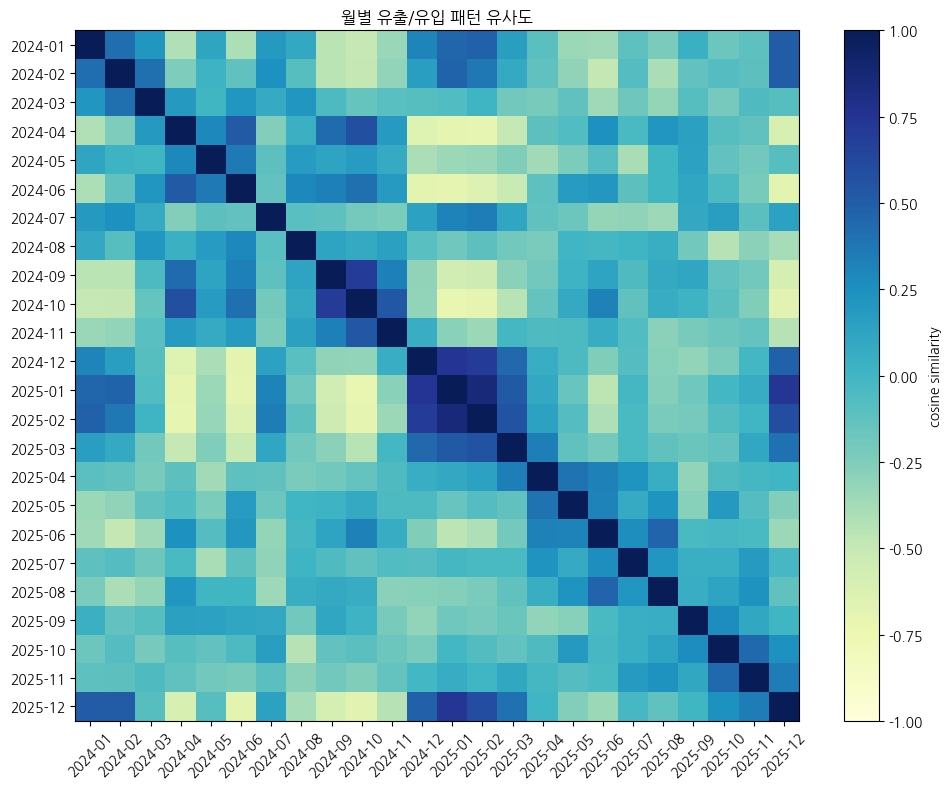

In [53]:
plt.figure(figsize=(10, 8))
plt.imshow(similarity_matrix.astype(float), cmap='YlGnBu', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='cosine similarity')
plt.xticks(range(len(similarity_matrix.columns)), similarity_matrix.columns, rotation=45)
plt.yticks(range(len(similarity_matrix.index)), similarity_matrix.index)
plt.title('월별 유출/유입 패턴 유사도')
plt.tight_layout()
plt.show()


## 22. 공선성 최소화용 피처 설계

초기 모델은 공선성 가능성이 큰 변수들을 제외하고 시작합니다.

- 제외: `불쾌지수`, `위도`, `경도`, `cluster_12_custom`, `LCD`, `QR`
- 제외: `weekday`와 `is_weekend`를 동시에 사용하지 않음
- 제외: `hour`와 `hour_sin/hour_cos`를 동시에 사용하지 않음
- 제외: 같은 시점의 `inflow_count`, `net_flow`는 `outflow_count` 예측 입력으로 사용하지 않음
- 제외: `outflow_use_min_mean`, `outflow_use_dist_mean`는 둘 다 쓰지 않고 하나만 사용


In [54]:
station_meta_small = station_meta[['시작_대여소_ID', 'LCD', 'QR']].copy()
station_meta_small['initial_bikes'] = station_meta_small[['LCD', 'QR']].fillna(0).sum(axis=1)
station_meta_small = station_meta_small[['시작_대여소_ID', 'initial_bikes']]

df_hourly_flow = df_hourly_flow.merge(
    station_meta_small.rename(columns={'시작_대여소_ID': '대여소_ID'}),
    on='대여소_ID',
    how='left'
)

df_hourly_flow['hour_sin'] = np.sin(2 * np.pi * df_hourly_flow['hour'] / 24)
df_hourly_flow['hour_cos'] = np.cos(2 * np.pi * df_hourly_flow['hour'] / 24)

display(df_hourly_flow[['대여소_ID', 'datetime', 'hour', 'hour_sin', 'hour_cos', 'initial_bikes']].head())


,대여소_ID,datetime,hour,hour_sin,hour_cos,initial_bikes
0,ST-464,2024-01-01 00:00:00,0,0.000000,1.000000,13.0
1,ST-464,2024-01-01 01:00:00,1,0.258819,0.965926,13.0
2,ST-464,2024-01-01 02:00:00,2,0.500000,0.866025,13.0
3,ST-464,2024-01-01 03:00:00,3,0.707107,0.707107,13.0
4,ST-464,2024-01-01 04:00:00,4,0.866025,0.500000,13.0


## 23. 저공선성 기본 피처셋 초안

아래 피처셋은 `outflow_count`를 1차 타깃으로 둘 때 사용하는 보수적인 시작안입니다.


In [55]:
target_col = 'outflow_count'

low_collinearity_features = [
    '온도',
    '습도',
    '강수량',
    '적설량',
    'hour_sin',
    'hour_cos',
    'is_holiday',
    '출퇴근시간',
    'outflow_use_dist_mean',
    'initial_bikes'
]

excluded_for_collinearity = [
    '불쾌지수',
    '위도', '경도', 'cluster_12_custom', 'LCD', 'QR',
    'weekday', 'is_weekend',
    'hour',
    'outflow_use_min_mean',
    'inflow_count', 'net_flow'
]

print('target_col:', target_col)
print('low_collinearity_features:', low_collinearity_features)
print('excluded_for_collinearity:', excluded_for_collinearity)


target_col: outflow_count
low_collinearity_features: ['온도', '습도', '강수량', '적설량', 'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간', 'outflow_use_dist_mean', 'initial_bikes']
excluded_for_collinearity: ['불쾌지수', '위도', '경도', 'cluster_12_custom', 'LCD', 'QR', 'weekday', 'is_weekend', 'hour', 'outflow_use_min_mean', 'inflow_count', 'net_flow']


## 24. 모델링용 테이블 확인


In [56]:
model_base_df = df_hourly_flow[['대여소_ID', 'datetime', target_col] + low_collinearity_features].copy()

display(model_base_df.head())
print('model_base_df shape:', model_base_df.shape)


,대여소_ID,datetime,outflow_count,온도,습도,강수량,적설량,hour_sin,hour_cos,is_holiday,출퇴근시간,outflow_use_dist_mean,initial_bikes
0,ST-464,2024-01-01 00:00:00,0.0,6.1,65.0,0.0,0.0,0.000000,1.000000,0,0,1052.0,13.0
1,ST-464,2024-01-01 01:00:00,0.0,6.1,65.0,0.0,0.0,0.258819,0.965926,0,0,1052.0,13.0
2,ST-464,2024-01-01 02:00:00,0.0,6.1,65.0,0.0,0.0,0.500000,0.866025,0,0,1052.0,13.0
3,ST-464,2024-01-01 03:00:00,0.0,6.1,65.0,0.0,0.0,0.707107,0.707107,0,0,1052.0,13.0
4,ST-464,2024-01-01 04:00:00,0.0,6.1,65.0,0.0,0.0,0.866025,0.500000,0,0,1052.0,13.0


model_base_df shape: (52632, 13)


## 25. 필요 대수 계산을 위한 모델링 원칙

하이퍼파라미터에 따라 필요 대수 추정값이 달라질 수 있으므로,
먼저 `outflow_count` 예측 모델을 시계열 검증으로 고르고 그 결과로 필요 대수를 계산합니다.


## 26. 저공선성 lag/rolling 피처 추가


In [57]:
model_df = model_base_df.sort_values(['대여소_ID', 'datetime']).copy()

model_df['year'] = model_df['datetime'].dt.year
model_df['month'] = model_df['datetime'].dt.month

model_df['lag_outflow_1h'] = model_df.groupby('대여소_ID')[target_col].shift(1)
model_df['lag_outflow_24h'] = model_df.groupby('대여소_ID')[target_col].shift(24)
model_df['rolling_outflow_3h'] = model_df.groupby('대여소_ID')[target_col].transform(lambda x: x.shift(1).rolling(3).mean())

model_df = model_df.dropna(subset=['lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h']).copy()

model_features = low_collinearity_features + [
    'lag_outflow_1h',
    'lag_outflow_24h',
    'rolling_outflow_3h'
]

display(model_df[['대여소_ID', 'datetime', target_col] + model_features].head())
print('model_features:', model_features)
print('model_df shape:', model_df.shape)


,대여소_ID,datetime,outflow_count,온도,습도,강수량,적설량,hour_sin,hour_cos,is_holiday,출퇴근시간,outflow_use_dist_mean,initial_bikes,lag_outflow_1h,lag_outflow_24h,rolling_outflow_3h
24,ST-464,2024-01-02 00:00:00,0.0,4.3,78.0,0.0,0.0,0.000000,1.000000,0,1,1552.0,13.0,0.0,0.0,0.0
25,ST-464,2024-01-02 01:00:00,0.0,4.3,78.0,0.0,0.0,0.258819,0.965926,0,1,1552.0,13.0,0.0,0.0,0.0
26,ST-464,2024-01-02 02:00:00,0.0,4.3,78.0,0.0,0.0,0.500000,0.866025,0,1,1552.0,13.0,0.0,0.0,0.0
27,ST-464,2024-01-02 03:00:00,0.0,4.3,78.0,0.0,0.0,0.707107,0.707107,0,1,1552.0,13.0,0.0,0.0,0.0
28,ST-464,2024-01-02 04:00:00,0.0,4.3,78.0,0.0,0.0,0.866025,0.500000,0,1,1552.0,13.0,0.0,0.0,0.0


model_features: ['온도', '습도', '강수량', '적설량', 'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간', 'outflow_use_dist_mean', 'initial_bikes', 'lag_outflow_1h', 'lag_outflow_24h', 'rolling_outflow_3h']
model_df shape: (52560, 18)


## 27. 후보 모델 및 하이퍼파라미터 탐색 범위


In [58]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from ast import literal_eval

validation_folds = [
    {'fold': 'Fold1', 'train_month_end': 3, 'valid_months': [4, 5]},
    {'fold': 'Fold2', 'train_month_end': 5, 'valid_months': [6, 7]},
    {'fold': 'Fold3', 'train_month_end': 7, 'valid_months': [8, 9]},
    {'fold': 'Fold4', 'train_month_end': 9, 'valid_months': [10, 11, 12]}
]

search_space = {
    'Ridge': {
        'model_class': Pipeline,
        'pipeline_steps': [('scaler', StandardScaler()), ('model', Ridge())],
        'param_grid': {'model__alpha': [0.1, 1.0, 10.0, 30.0]}
    },
    'RandomForest': {
        'model_class': RandomForestRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'ExtraTrees': {
        'model_class': ExtraTreesRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5, 10]
        }
    },
    'HistGradientBoosting': {
        'model_class': HistGradientBoostingRegressor,
        'fixed_params': {'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [300, 500],
            'max_depth': [6, 8, 10],
            'min_samples_leaf': [10, 20],
            'l2_regularization': [0.0, 0.1]
        }
    }
}


## 28. 시계열 검증으로 최적 모델 선택


In [61]:
validation_search_results = []
validation_fold_results = []

for model_name, cfg in search_space.items():
    for params in ParameterGrid(cfg['param_grid']):
        fold_scores = []

        for fold_cfg in validation_folds:
            fold_train = model_df[(model_df['year'] == 2024) & (model_df['month'] <= fold_cfg['train_month_end'])].copy()
            fold_valid = model_df[(model_df['year'] == 2024) & (model_df['month'].isin(fold_cfg['valid_months']))].copy()

            if len(fold_train) == 0 or len(fold_valid) == 0:
                continue

            X_fold_train = fold_train[model_features].fillna(0)
            y_fold_train = fold_train[target_col]
            X_fold_valid = fold_valid[model_features].fillna(0)
            y_fold_valid = fold_valid[target_col]

            if cfg['model_class'] is Pipeline:
                model = cfg['model_class'](cfg['pipeline_steps'])
                model.set_params(**params)
            else:
                all_params = {}
                all_params.update(cfg.get('fixed_params', {}))
                all_params.update(params)
                model = cfg['model_class'](**all_params)

            model.fit(X_fold_train, np.log1p(y_fold_train))
            train_pred = np.clip(np.expm1(model.predict(X_fold_train)), 0, None)
            valid_pred = np.clip(np.expm1(model.predict(X_fold_valid)), 0, None)

            fold_row = {
                '모델': model_name,
                '파라미터': str(params),
                'fold': fold_cfg['fold'],
                'Train_MAE': mean_absolute_error(y_fold_train, train_pred),
                'Train_RMSE': np.sqrt(mean_squared_error(y_fold_train, train_pred)),
                'Train_R2': r2_score(y_fold_train, train_pred),
                'Valid_MAE': mean_absolute_error(y_fold_valid, valid_pred),
                'Valid_RMSE': np.sqrt(mean_squared_error(y_fold_valid, valid_pred)),
                'Valid_R2': r2_score(y_fold_valid, valid_pred)
            }
            fold_scores.append(fold_row)
            validation_fold_results.append(fold_row)

        if len(fold_scores) == 0:
            continue

        validation_search_results.append({
            '모델': model_name,
            '파라미터': str(params),
            'Avg_Train_MAE': float(np.mean([x['Train_MAE'] for x in fold_scores])),
            'Avg_Train_RMSE': float(np.mean([x['Train_RMSE'] for x in fold_scores])),
            'Avg_Train_R2': float(np.mean([x['Train_R2'] for x in fold_scores])),
            'Avg_Valid_MAE': float(np.mean([x['Valid_MAE'] for x in fold_scores])),
            'Avg_Valid_RMSE': float(np.mean([x['Valid_RMSE'] for x in fold_scores])),
            'Avg_Valid_R2': float(np.mean([x['Valid_R2'] for x in fold_scores])),
            '사용_Fold수': len(fold_scores)
        })

validation_result_table = pd.DataFrame(validation_search_results).sort_values(['Avg_Valid_RMSE', 'Avg_Valid_MAE'])
validation_fold_table = pd.DataFrame(validation_fold_results)
best_validation_table = validation_result_table.groupby('모델', as_index=False).first().sort_values('Avg_Valid_RMSE')

display(best_validation_table)
print('검증 기준 최고 모델:', best_validation_table.iloc[0]['모델'])
print('검증 기준 최고 파라미터:', best_validation_table.iloc[0]['파라미터'])


,모델,파라미터,Avg_Train_MAE,Avg_Train_RMSE,Avg_Train_R2,Avg_Valid_MAE,Avg_Valid_RMSE,Avg_Valid_R2,사용_Fold수
0,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es...",0.363565,0.751469,0.580455,0.605721,1.108728,0.294551,4
1,HistGradientBoosting,"{'l2_regularization': 0.0, 'learning_rate': 0....",0.410658,0.828676,0.489789,0.621914,1.123073,0.276896,4
2,RandomForest,"{'max_depth': None, 'min_samples_leaf': 5, 'n_...",0.365623,0.771466,0.553858,0.650943,1.138226,0.256684,4
3,Ridge,{'model__alpha': 0.1},0.585845,1.114727,0.072225,0.702185,1.277630,0.063434,4


검증 기준 최고 모델: ExtraTrees
검증 기준 최고 파라미터: {'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 200}


## 29. 최적 모델로 시간대별 필요 대수 계산

현재는 단순하게
`필요 대수 = max(0, 예측 유출량 + 안전 버퍼 - 초기 보유 대수)`
로 계산합니다.


In [62]:
best_model_name = best_validation_table.iloc[0]['모델']
best_param_text = best_validation_table.iloc[0]['파라미터']
best_cfg = search_space[best_model_name]
best_params = literal_eval(best_param_text)

if best_cfg['model_class'] is Pipeline:
    final_best_model = best_cfg['model_class'](best_cfg['pipeline_steps'])
    final_best_model.set_params(**best_params)
else:
    final_param_dict = {}
    final_param_dict.update(best_cfg.get('fixed_params', {}))
    final_param_dict.update(best_params)
    final_best_model = best_cfg['model_class'](**final_param_dict)

train_2024 = model_df[model_df['year'] == 2024].copy()
test_2025 = model_df[model_df['year'] == 2025].copy()

X_train_2024 = train_2024[model_features].fillna(0)
y_train_2024 = train_2024[target_col]
X_test_2025 = test_2025[model_features].fillna(0)
y_test_2025 = test_2025[target_col]

final_best_model.fit(X_train_2024, np.log1p(y_train_2024))
pred_outflow_2025 = np.clip(np.expm1(final_best_model.predict(X_test_2025)), 0, None)
train_pred_2024 = np.clip(np.expm1(final_best_model.predict(X_train_2024)), 0, None)

best_fold_score_table = validation_fold_table[
    (validation_fold_table['모델'] == best_model_name)
    & (validation_fold_table['파라미터'] == best_param_text)
].copy().sort_values('fold')

score_summary_table = pd.DataFrame([
    {
        '구간': 'Train_2024',
        'MAE': mean_absolute_error(y_train_2024, train_pred_2024),
        'RMSE': np.sqrt(mean_squared_error(y_train_2024, train_pred_2024)),
        'R2': r2_score(y_train_2024, train_pred_2024)
    },
    {
        '구간': 'Valid_2024_FoldAvg',
        'MAE': best_fold_score_table['Valid_MAE'].mean(),
        'RMSE': best_fold_score_table['Valid_RMSE'].mean(),
        'R2': best_fold_score_table['Valid_R2'].mean()
    },
    {
        '구간': 'Test_2025',
        'MAE': mean_absolute_error(y_test_2025, pred_outflow_2025),
        'RMSE': np.sqrt(mean_squared_error(y_test_2025, pred_outflow_2025)),
        'R2': r2_score(y_test_2025, pred_outflow_2025)
    }
]).round(4)

test_score_by_station = test_2025[['대여소_ID']].copy()
test_score_by_station['actual'] = y_test_2025.to_numpy()
test_score_by_station['pred'] = pred_outflow_2025
test_score_by_station = test_score_by_station.groupby('대여소_ID').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['actual'], x['pred']),
        'RMSE': np.sqrt(mean_squared_error(x['actual'], x['pred'])),
        'R2': r2_score(x['actual'], x['pred']),
        'actual_std': x['actual'].std()
    })
).reset_index().round(4)

target_diagnostic_table = pd.DataFrame([
    {
        '구간': 'Train_2024',
        'target_mean': y_train_2024.mean(),
        'target_std': y_train_2024.std(),
        'zero_ratio': (y_train_2024 == 0).mean()
    },
    {
        '구간': 'Test_2025',
        'target_mean': y_test_2025.mean(),
        'target_std': y_test_2025.std(),
        'zero_ratio': (y_test_2025 == 0).mean()
    }
]).round(4)

safety_buffer = float(np.quantile(np.maximum(y_train_2024 - train_pred_2024, 0), 0.9))

need_bike_df = test_2025[['대여소_ID', 'datetime', 'initial_bikes', target_col]].copy()
need_bike_df['pred_outflow_count'] = pred_outflow_2025
need_bike_df['safety_buffer'] = safety_buffer
need_bike_df['needed_bikes'] = np.clip(
    np.ceil(need_bike_df['pred_outflow_count'] + safety_buffer - need_bike_df['initial_bikes']),
    0,
    None
)

need_bike_summary = need_bike_df.groupby('대여소_ID', as_index=False).agg({
    'pred_outflow_count': ['mean', 'max'],
    'needed_bikes': ['mean', 'max']
})
need_bike_summary.columns = [
    '대여소_ID',
    'pred_outflow_mean', 'pred_outflow_max',
    'needed_bikes_mean', 'needed_bikes_max'
]

display(score_summary_table)
display(best_fold_score_table)
display(test_score_by_station)
display(target_diagnostic_table)
display(need_bike_df.head())
display(need_bike_summary)
print('선택 모델:', best_model_name)
print('선택 파라미터:', best_param_text)
print('safety_buffer:', round(safety_buffer, 3))


,구간,MAE,RMSE,R2
0,Train_2024,0.4595,0.8988,0.4867
1,Valid_2024_FoldAvg,0.6057,1.1087,0.2946
2,Test_2025,0.4949,0.9323,0.2569


,모델,파라미터,fold,Train_MAE,Train_RMSE,Train_R2,Valid_MAE,Valid_RMSE,Valid_R2
64,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es...",Fold1,0.266937,0.598146,0.647709,0.630801,1.154770,0.304333
65,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es...",Fold2,0.357295,0.735770,0.610733,0.627779,1.088338,0.295757
66,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es...",Fold3,0.398831,0.816025,0.548657,0.580589,1.075215,0.287439
67,ExtraTrees,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es...",Fold4,0.431195,0.855934,0.514720,0.583715,1.116587,0.290674


,대여소_ID,MAE,RMSE,R2,actual_std
0,ST-464,0.3164,0.6897,0.1341,0.7412
1,ST-479,0.4806,0.8941,0.2195,1.0120
2,ST-481,0.6877,1.1544,0.2745,1.3554


,구간,target_mean,target_std,zero_ratio
0,Train_2024,0.5422,1.2545,0.7935
1,Test_2025,0.4537,1.0816,0.8162


,대여소_ID,datetime,initial_bikes,outflow_count,pred_outflow_count,safety_buffer,needed_bikes
8784,ST-464,2025-01-01 00:00:00,13.0,0.0,0.000199,1.393592,0.0
8785,ST-464,2025-01-01 01:00:00,13.0,0.0,0.001019,1.393592,0.0
8786,ST-464,2025-01-01 02:00:00,13.0,0.0,0.000598,1.393592,0.0
8787,ST-464,2025-01-01 03:00:00,13.0,0.0,0.000034,1.393592,0.0
8788,ST-464,2025-01-01 04:00:00,13.0,0.0,0.000265,1.393592,0.0


,대여소_ID,pred_outflow_mean,pred_outflow_max,needed_bikes_mean,needed_bikes_max
0,ST-464,0.166962,2.100583,0.0,0.0
1,ST-479,0.317895,3.132967,0.0,0.0
2,ST-481,0.533303,6.372594,0.0,0.0


선택 모델: ExtraTrees
선택 파라미터: {'max_depth': 12, 'min_samples_leaf': 1, 'n_estimators': 200}
safety_buffer: 1.394


## 30. 3시간 블록 + Poisson 대안 모델

1시간 단위 `outflow_count`는 0 비율이 높아서 R2가 낮게 나올 수 있습니다.
그래서 아래에서는
- 타깃을 `3시간 블록 outflow`로 바꾸고
- `PoissonRegressor`, `HistGradientBoosting(loss='poisson')`를 비교하고
- `initial_bikes` 대신 `현재 재고 추정치`로 필요 대수를 계산합니다.


In [63]:
flow_hourly_model = df_hourly_flow.sort_values(['대여소_ID', 'datetime']).copy()
flow_hourly_model['estimated_stock_start'] = (
    flow_hourly_model['initial_bikes']
    + flow_hourly_model.groupby('대여소_ID')['net_flow'].transform(lambda x: x.shift(1).fillna(0).cumsum())
).clip(lower=0)

flow_hourly_model['block_datetime'] = flow_hourly_model['datetime'].dt.floor('3h')

model_3h = flow_hourly_model.groupby(['대여소_ID', 'block_datetime'], as_index=False).agg({
    'outflow_count': 'sum',
    'inflow_count': 'sum',
    'net_flow': 'sum',
    '온도': 'mean',
    '습도': 'mean',
    '강수량': 'sum',
    '적설량': 'sum',
    'is_holiday': 'max',
    '출퇴근시간': 'max',
    'outflow_use_dist_mean': 'mean',
    'initial_bikes': 'first',
    'estimated_stock_start': 'first'
})

model_3h['year'] = model_3h['block_datetime'].dt.year
model_3h['month'] = model_3h['block_datetime'].dt.month
model_3h['block_hour'] = model_3h['block_datetime'].dt.hour
model_3h['hour_sin'] = np.sin(2 * np.pi * model_3h['block_hour'] / 24)
model_3h['hour_cos'] = np.cos(2 * np.pi * model_3h['block_hour'] / 24)

target_col_3h = 'outflow_count'

model_3h['lag_outflow_1block'] = model_3h.groupby('대여소_ID')[target_col_3h].shift(1)
model_3h['lag_outflow_2block'] = model_3h.groupby('대여소_ID')[target_col_3h].shift(2)
model_3h['lag_outflow_8block'] = model_3h.groupby('대여소_ID')[target_col_3h].shift(8)
model_3h['lag_inflow_1block'] = model_3h.groupby('대여소_ID')['inflow_count'].shift(1)
model_3h['rolling_outflow_2block'] = model_3h.groupby('대여소_ID')[target_col_3h].transform(lambda x: x.shift(1).rolling(2).mean())
model_3h['rolling_outflow_8block'] = model_3h.groupby('대여소_ID')[target_col_3h].transform(lambda x: x.shift(1).rolling(8).mean())

model_3h = model_3h.dropna(subset=[
    'lag_outflow_1block', 'lag_outflow_2block', 'lag_outflow_8block',
    'lag_inflow_1block', 'rolling_outflow_2block', 'rolling_outflow_8block'
]).copy()

model_features_3h = [
    '온도', '습도', '강수량', '적설량',
    'hour_sin', 'hour_cos', 'is_holiday', '출퇴근시간',
    'outflow_use_dist_mean', 'initial_bikes', 'estimated_stock_start',
    'lag_outflow_1block', 'lag_outflow_2block', 'lag_outflow_8block',
    'lag_inflow_1block', 'rolling_outflow_2block', 'rolling_outflow_8block'
]

target_diagnostic_3h_base = pd.DataFrame([
    {
        '구간': 'Train_2024_3h',
        'target_mean': model_3h.loc[model_3h['year'] == 2024, target_col_3h].mean(),
        'target_std': model_3h.loc[model_3h['year'] == 2024, target_col_3h].std(),
        'zero_ratio': (model_3h.loc[model_3h['year'] == 2024, target_col_3h] == 0).mean()
    },
    {
        '구간': 'Test_2025_3h',
        'target_mean': model_3h.loc[model_3h['year'] == 2025, target_col_3h].mean(),
        'target_std': model_3h.loc[model_3h['year'] == 2025, target_col_3h].std(),
        'zero_ratio': (model_3h.loc[model_3h['year'] == 2025, target_col_3h] == 0).mean()
    }
]).round(4)

display(model_3h[['대여소_ID', 'block_datetime', target_col_3h] + model_features_3h].head())
display(target_diagnostic_3h_base)
print('model_3h shape:', model_3h.shape)


,대여소_ID,block_datetime,outflow_count,온도,습도,강수량,적설량,hour_sin,hour_cos,is_holiday,출퇴근시간,outflow_use_dist_mean,initial_bikes,estimated_stock_start,lag_outflow_1block,lag_outflow_2block,lag_outflow_8block,lag_inflow_1block,rolling_outflow_2block,rolling_outflow_8block
8,ST-464,2024-01-02 00:00:00,0.0,4.3,78.0,0.0,0.0,0.000000e+00,1.000000e+00,0,1,1552.0,13.0,10.0,0.0,0.0,0.0,0.0,0.0,0.5
9,ST-464,2024-01-02 03:00:00,0.0,4.3,78.0,0.0,0.0,7.071068e-01,7.071068e-01,0,1,1552.0,13.0,10.0,0.0,0.0,0.0,0.0,0.0,0.5
10,ST-464,2024-01-02 06:00:00,0.0,4.3,78.0,0.0,0.0,1.000000e+00,6.123234e-17,0,1,1552.0,13.0,10.0,0.0,0.0,0.0,0.0,0.0,0.5
11,ST-464,2024-01-02 09:00:00,0.0,4.3,78.0,0.0,0.0,7.071068e-01,-7.071068e-01,0,1,1552.0,13.0,10.0,0.0,0.0,0.0,0.0,0.0,0.5
12,ST-464,2024-01-02 12:00:00,0.0,4.3,78.0,0.0,0.0,1.224647e-16,-1.000000e+00,0,1,1552.0,13.0,10.0,0.0,0.0,2.0,0.0,0.0,0.5


,구간,target_mean,target_std,zero_ratio
0,Train_2024_3h,1.6265,2.6475,0.5588
1,Test_2025_3h,1.3610,2.1519,0.5957


model_3h shape: (17520, 25)


In [64]:
from sklearn.linear_model import PoissonRegressor

search_space_3h = {
    'PoissonRegressor': {
        'model_class': Pipeline,
        'pipeline_steps': [('scaler', StandardScaler()), ('model', PoissonRegressor(max_iter=500))],
        'param_grid': {'model__alpha': [0.1, 0.5, 1.0, 3.0]},
        'target_mode': 'raw'
    },
    'HistGradientBoosting_Poisson': {
        'model_class': HistGradientBoostingRegressor,
        'fixed_params': {'loss': 'poisson', 'random_state': 42},
        'param_grid': {
            'learning_rate': [0.03, 0.05],
            'max_iter': [300, 500],
            'max_depth': [6, 8],
            'min_samples_leaf': [10, 20],
            'l2_regularization': [0.0, 0.1]
        },
        'target_mode': 'raw'
    },
    'ExtraTrees_3h': {
        'model_class': ExtraTreesRegressor,
        'fixed_params': {'random_state': 42, 'n_jobs': -1},
        'param_grid': {
            'n_estimators': [200],
            'max_depth': [8, 12, None],
            'min_samples_leaf': [1, 5]
        },
        'target_mode': 'log1p'
    }
}

def build_model_from_cfg(cfg, params):
    if cfg['model_class'] is Pipeline:
        model = cfg['model_class'](cfg['pipeline_steps'])
        model.set_params(**params)
        return model

    all_params = {}
    all_params.update(cfg.get('fixed_params', {}))
    all_params.update(params)
    return cfg['model_class'](**all_params)

def fit_predict_from_cfg(model, cfg, X_train, y_train, X_pred):
    if cfg.get('target_mode') == 'log1p':
        model.fit(X_train, np.log1p(y_train))
        return np.clip(np.expm1(model.predict(X_pred)), 0, None)

    model.fit(X_train, y_train)
    return np.clip(model.predict(X_pred), 0, None)


In [65]:
validation_search_results_3h = []
validation_fold_results_3h = []

for model_name, cfg in search_space_3h.items():
    for params in ParameterGrid(cfg['param_grid']):
        fold_scores = []

        for fold_cfg in validation_folds:
            fold_train = model_3h[(model_3h['year'] == 2024) & (model_3h['month'] <= fold_cfg['train_month_end'])].copy()
            fold_valid = model_3h[(model_3h['year'] == 2024) & (model_3h['month'].isin(fold_cfg['valid_months']))].copy()

            if len(fold_train) == 0 or len(fold_valid) == 0:
                continue

            X_fold_train = fold_train[model_features_3h].fillna(0)
            y_fold_train = fold_train[target_col_3h]
            X_fold_valid = fold_valid[model_features_3h].fillna(0)
            y_fold_valid = fold_valid[target_col_3h]

            model = build_model_from_cfg(cfg, params)
            train_pred = fit_predict_from_cfg(model, cfg, X_fold_train, y_fold_train, X_fold_train)
            valid_pred = fit_predict_from_cfg(model, cfg, X_fold_train, y_fold_train, X_fold_valid)

            fold_row = {
                '모델': model_name,
                '파라미터': str(params),
                'fold': fold_cfg['fold'],
                'Train_MAE': mean_absolute_error(y_fold_train, train_pred),
                'Train_RMSE': np.sqrt(mean_squared_error(y_fold_train, train_pred)),
                'Train_R2': r2_score(y_fold_train, train_pred),
                'Valid_MAE': mean_absolute_error(y_fold_valid, valid_pred),
                'Valid_RMSE': np.sqrt(mean_squared_error(y_fold_valid, valid_pred)),
                'Valid_R2': r2_score(y_fold_valid, valid_pred)
            }
            fold_scores.append(fold_row)
            validation_fold_results_3h.append(fold_row)

        if len(fold_scores) == 0:
            continue

        validation_search_results_3h.append({
            '모델': model_name,
            '파라미터': str(params),
            'Avg_Train_MAE': float(np.mean([x['Train_MAE'] for x in fold_scores])),
            'Avg_Train_RMSE': float(np.mean([x['Train_RMSE'] for x in fold_scores])),
            'Avg_Train_R2': float(np.mean([x['Train_R2'] for x in fold_scores])),
            'Avg_Valid_MAE': float(np.mean([x['Valid_MAE'] for x in fold_scores])),
            'Avg_Valid_RMSE': float(np.mean([x['Valid_RMSE'] for x in fold_scores])),
            'Avg_Valid_R2': float(np.mean([x['Valid_R2'] for x in fold_scores])),
            '사용_Fold수': len(fold_scores)
        })

validation_result_table_3h = pd.DataFrame(validation_search_results_3h).sort_values(['Avg_Valid_RMSE', 'Avg_Valid_MAE'])
validation_fold_table_3h = pd.DataFrame(validation_fold_results_3h)
best_validation_table_3h = validation_result_table_3h.groupby('모델', as_index=False).first().sort_values('Avg_Valid_RMSE')

display(best_validation_table_3h)
print('3시간 블록 검증 기준 최고 모델:', best_validation_table_3h.iloc[0]['모델'])
print('3시간 블록 검증 기준 최고 파라미터:', best_validation_table_3h.iloc[0]['파라미터'])


,모델,파라미터,Avg_Train_MAE,Avg_Train_RMSE,Avg_Train_R2,Avg_Valid_MAE,Avg_Valid_RMSE,Avg_Valid_R2,사용_Fold수
1,HistGradientBoosting_Poisson,"{'l2_regularization': 0.1, 'learning_rate': 0....",0.736302,1.089232,0.795159,1.343689,2.047437,0.461345,4
0,ExtraTrees_3h,"{'max_depth': 12, 'min_samples_leaf': 1, 'n_es...",0.535256,0.960750,0.839829,1.343789,2.065949,0.451661,4
2,PoissonRegressor,{'model__alpha': 1.0},1.437714,2.074996,0.250896,1.690377,2.456491,0.226363,4


3시간 블록 검증 기준 최고 모델: HistGradientBoosting_Poisson
3시간 블록 검증 기준 최고 파라미터: {'l2_regularization': 0.1, 'learning_rate': 0.03, 'max_depth': 8, 'max_iter': 300, 'min_samples_leaf': 20}


## 31. 현재 재고 추정치 기반 필요 대수 계산

여기서는 `초기 보유 대수`가 아니라 각 3시간 블록 시작 시점의 `estimated_stock_start`를 기준으로 부족 대수를 계산합니다.


In [66]:
best_model_name_3h = best_validation_table_3h.iloc[0]['모델']
best_param_text_3h = best_validation_table_3h.iloc[0]['파라미터']
best_cfg_3h = search_space_3h[best_model_name_3h]
best_params_3h = literal_eval(best_param_text_3h)

train_2024_3h = model_3h[model_3h['year'] == 2024].copy()
test_2025_3h = model_3h[model_3h['year'] == 2025].copy()

X_train_2024_3h = train_2024_3h[model_features_3h].fillna(0)
y_train_2024_3h = train_2024_3h[target_col_3h]
X_test_2025_3h = test_2025_3h[model_features_3h].fillna(0)
y_test_2025_3h = test_2025_3h[target_col_3h]

final_best_model_3h = build_model_from_cfg(best_cfg_3h, best_params_3h)
pred_outflow_2025_3h = fit_predict_from_cfg(final_best_model_3h, best_cfg_3h, X_train_2024_3h, y_train_2024_3h, X_test_2025_3h)
train_pred_2024_3h = fit_predict_from_cfg(final_best_model_3h, best_cfg_3h, X_train_2024_3h, y_train_2024_3h, X_train_2024_3h)

best_fold_score_table_3h = validation_fold_table_3h[
    (validation_fold_table_3h['모델'] == best_model_name_3h)
    & (validation_fold_table_3h['파라미터'] == best_param_text_3h)
].copy().sort_values('fold')

score_summary_table_3h = pd.DataFrame([
    {
        '구간': 'Train_2024_3h',
        'MAE': mean_absolute_error(y_train_2024_3h, train_pred_2024_3h),
        'RMSE': np.sqrt(mean_squared_error(y_train_2024_3h, train_pred_2024_3h)),
        'R2': r2_score(y_train_2024_3h, train_pred_2024_3h)
    },
    {
        '구간': 'Valid_2024_3h_FoldAvg',
        'MAE': best_fold_score_table_3h['Valid_MAE'].mean(),
        'RMSE': best_fold_score_table_3h['Valid_RMSE'].mean(),
        'R2': best_fold_score_table_3h['Valid_R2'].mean()
    },
    {
        '구간': 'Test_2025_3h',
        'MAE': mean_absolute_error(y_test_2025_3h, pred_outflow_2025_3h),
        'RMSE': np.sqrt(mean_squared_error(y_test_2025_3h, pred_outflow_2025_3h)),
        'R2': r2_score(y_test_2025_3h, pred_outflow_2025_3h)
    }
]).round(4)

test_score_by_station_3h = test_2025_3h[['대여소_ID']].copy()
test_score_by_station_3h['actual'] = y_test_2025_3h.to_numpy()
test_score_by_station_3h['pred'] = pred_outflow_2025_3h
test_score_by_station_3h = test_score_by_station_3h.groupby('대여소_ID').apply(
    lambda x: pd.Series({
        'MAE': mean_absolute_error(x['actual'], x['pred']),
        'RMSE': np.sqrt(mean_squared_error(x['actual'], x['pred'])),
        'R2': r2_score(x['actual'], x['pred']),
        'actual_std': x['actual'].std(),
        'zero_ratio': (x['actual'] == 0).mean()
    })
).reset_index().round(4)

safety_buffer_3h = float(np.quantile(np.maximum(y_train_2024_3h - train_pred_2024_3h, 0), 0.9))

need_bike_df_3h = test_2025_3h[['대여소_ID', 'block_datetime', 'estimated_stock_start', 'initial_bikes', target_col_3h]].copy()
need_bike_df_3h['pred_outflow_3h'] = pred_outflow_2025_3h
need_bike_df_3h['safety_buffer_3h'] = safety_buffer_3h
need_bike_df_3h['needed_bikes_stock_based'] = np.clip(
    np.ceil(need_bike_df_3h['pred_outflow_3h'] + safety_buffer_3h - need_bike_df_3h['estimated_stock_start']),
    0,
    None
)

need_bike_summary_3h = need_bike_df_3h.groupby('대여소_ID', as_index=False).agg({
    'pred_outflow_3h': ['mean', 'max'],
    'estimated_stock_start': ['mean', 'min'],
    'needed_bikes_stock_based': ['mean', 'max']
})
need_bike_summary_3h.columns = [
    '대여소_ID',
    'pred_outflow_3h_mean', 'pred_outflow_3h_max',
    'estimated_stock_mean', 'estimated_stock_min',
    'needed_bikes_mean', 'needed_bikes_max'
]

display(score_summary_table_3h)
display(best_fold_score_table_3h)
display(test_score_by_station_3h)
display(need_bike_df_3h.head())
display(need_bike_summary_3h)
print('3시간 블록 선택 모델:', best_model_name_3h)
print('3시간 블록 선택 파라미터:', best_param_text_3h)
print('3시간 블록 safety_buffer:', round(safety_buffer_3h, 3))


,구간,MAE,RMSE,R2
0,Train_2024_3h,0.9456,1.3783,0.7289
1,Valid_2024_3h_FoldAvg,1.3437,2.0474,0.4613
2,Test_2025_3h,1.1996,1.8280,0.2783


,모델,파라미터,fold,Train_MAE,Train_RMSE,Train_R2,Valid_MAE,Valid_RMSE,Valid_R2
100,HistGradientBoosting_Poisson,"{'l2_regularization': 0.1, 'learning_rate': 0....",Fold1,0.544322,0.798734,0.847443,1.461611,2.208386,0.425247
101,HistGradientBoosting_Poisson,"{'l2_regularization': 0.1, 'learning_rate': 0....",Fold2,0.718733,1.071956,0.809112,1.351687,2.084256,0.392857
102,HistGradientBoosting_Poisson,"{'l2_regularization': 0.1, 'learning_rate': 0....",Fold3,0.810042,1.205673,0.771229,1.236490,1.895431,0.524326
103,HistGradientBoosting_Poisson,"{'l2_regularization': 0.1, 'learning_rate': 0....",Fold4,0.872113,1.280566,0.752854,1.324968,2.001676,0.502949


,대여소_ID,MAE,RMSE,R2,actual_std,zero_ratio
0,ST-464,0.8269,1.1873,0.2122,1.3379,0.7075
1,ST-479,1.0861,1.5413,0.3268,1.8789,0.5901
2,ST-481,1.6858,2.4979,0.1876,2.7718,0.4894


,대여소_ID,block_datetime,estimated_stock_start,initial_bikes,outflow_count,pred_outflow_3h,safety_buffer_3h,needed_bikes_stock_based
2928,ST-464,2025-01-01 00:00:00,358.0,13.0,0.0,0.190927,1.644717,0.0
2929,ST-464,2025-01-01 03:00:00,358.0,13.0,0.0,0.094802,1.644717,0.0
2930,ST-464,2025-01-01 06:00:00,358.0,13.0,0.0,0.707838,1.644717,0.0
2931,ST-464,2025-01-01 09:00:00,358.0,13.0,0.0,0.425389,1.644717,0.0
2932,ST-464,2025-01-01 12:00:00,358.0,13.0,0.0,0.285234,1.644717,0.0


,대여소_ID,pred_outflow_3h_mean,pred_outflow_3h_max,estimated_stock_mean,estimated_stock_min,needed_bikes_mean,needed_bikes_max
0,ST-464,0.732660,3.900060,323.750342,228.0,0.000000,0.0
1,ST-479,1.315842,6.464541,2315.016781,1582.0,0.000000,0.0
2,ST-481,2.646948,24.933461,0.000000,0.0,4.781164,27.0


3시간 블록 선택 모델: HistGradientBoosting_Poisson
3시간 블록 선택 파라미터: {'l2_regularization': 0.1, 'learning_rate': 0.03, 'max_depth': 8, 'max_iter': 300, 'min_samples_leaf': 20}
3시간 블록 safety_buffer: 1.645


## 32. 전체 분석 결과 요약 시각화

아래 시각화는 지금까지 만든 핵심 결과를 한 번에 비교하기 위한 요약 자료입니다.


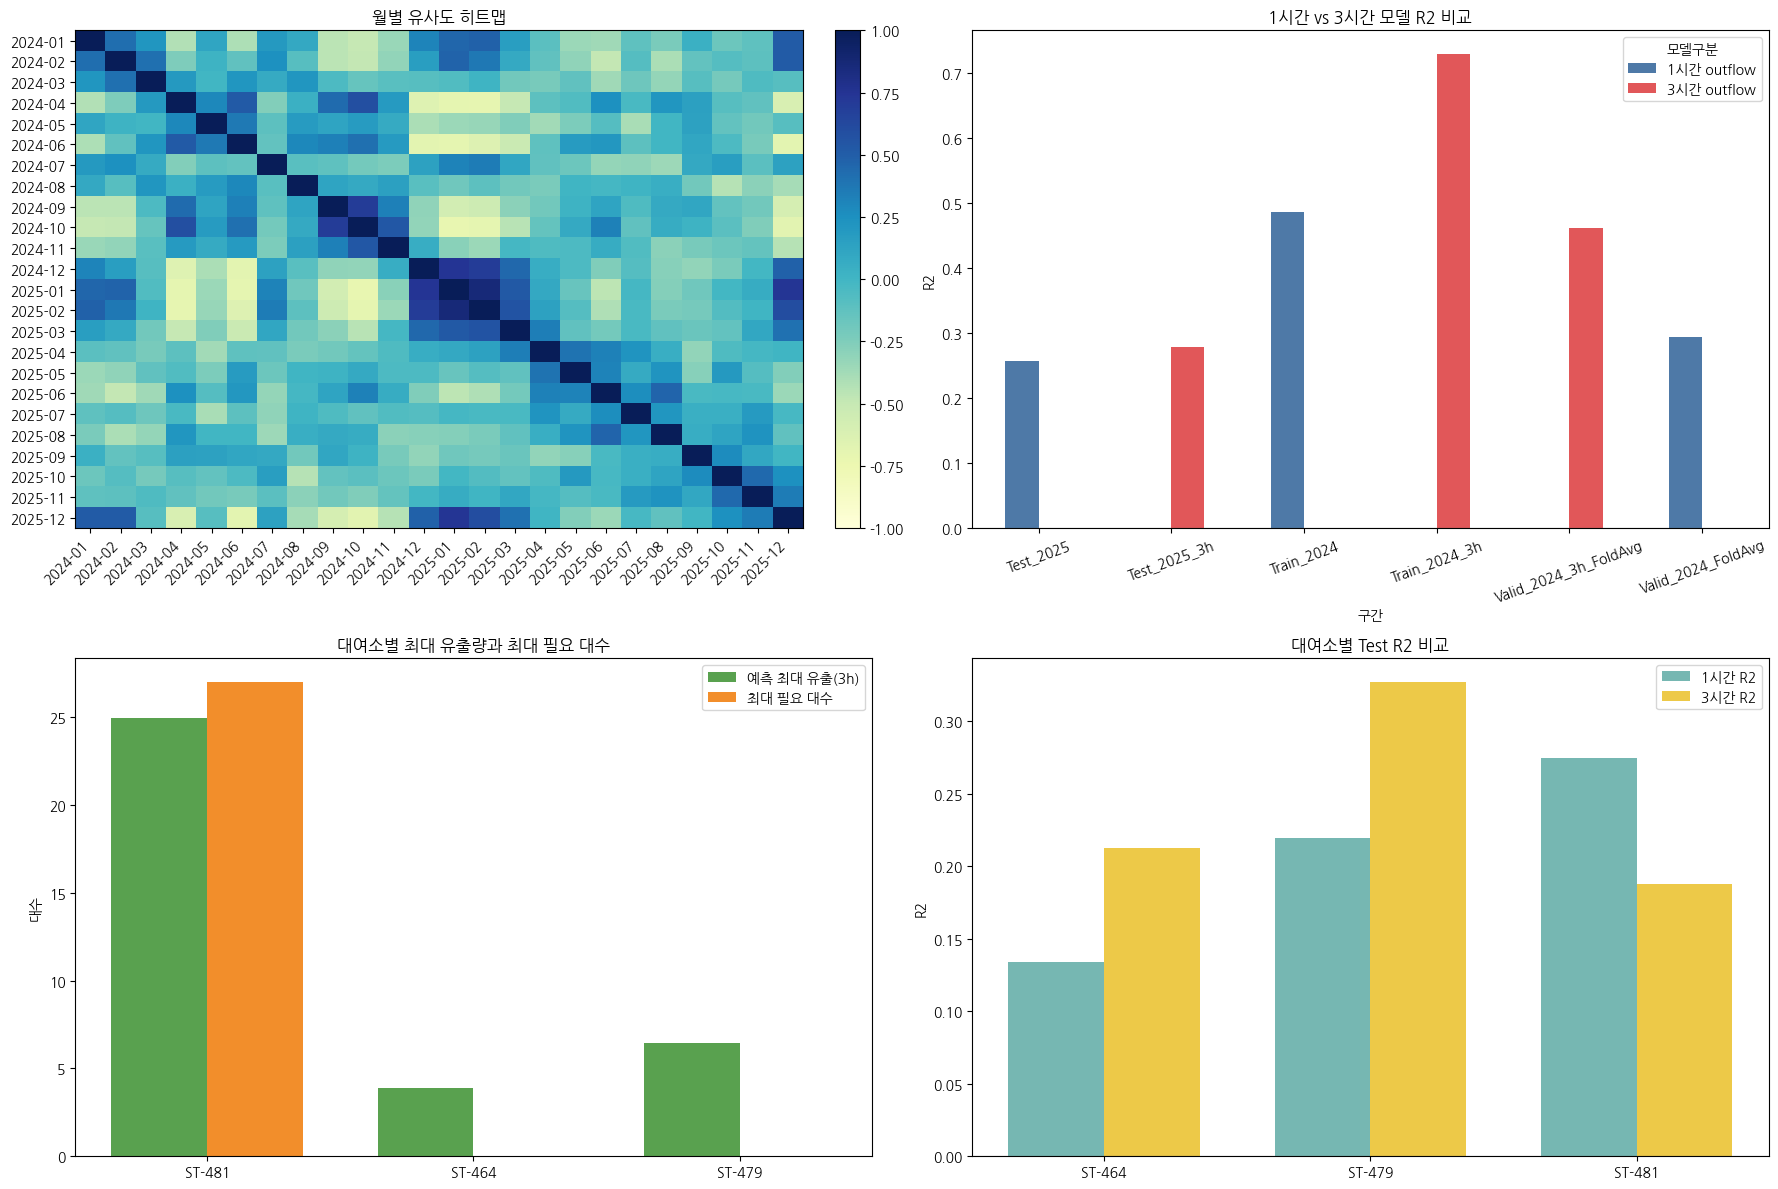

In [67]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sim_values = similarity_matrix.astype(float).to_numpy()
im = axes[0, 0].imshow(sim_values, cmap='YlGnBu', aspect='auto', vmin=-1, vmax=1)
axes[0, 0].set_xticks(range(len(similarity_matrix.columns)))
axes[0, 0].set_xticklabels(similarity_matrix.columns, rotation=45, ha='right')
axes[0, 0].set_yticks(range(len(similarity_matrix.index)))
axes[0, 0].set_yticklabels(similarity_matrix.index)
axes[0, 0].set_title('월별 유사도 히트맵')
fig.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

score_compare = pd.concat([
    score_summary_table.assign(모델구분='1시간 outflow'),
    score_summary_table_3h.assign(모델구분='3시간 outflow')
], ignore_index=True)

score_pivot = score_compare.pivot(index='구간', columns='모델구분', values='R2')
score_pivot.plot(kind='bar', ax=axes[0, 1], color=['#4E79A7', '#E15759'])
axes[0, 1].set_title('1시간 vs 3시간 모델 R2 비교')
axes[0, 1].set_ylabel('R2')
axes[0, 1].axhline(0, color='gray', linewidth=0.8)
axes[0, 1].tick_params(axis='x', rotation=20)
axes[0, 1].legend(title='모델구분')

need_bike_plot_df = need_bike_summary_3h.sort_values('needed_bikes_max', ascending=False)
x_pos = np.arange(len(need_bike_plot_df))
axes[1, 0].bar(x_pos - 0.18, need_bike_plot_df['pred_outflow_3h_max'], width=0.36, label='예측 최대 유출(3h)', color='#59A14F')
axes[1, 0].bar(x_pos + 0.18, need_bike_plot_df['needed_bikes_max'], width=0.36, label='최대 필요 대수', color='#F28E2B')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(need_bike_plot_df['대여소_ID'])
axes[1, 0].set_title('대여소별 최대 유출량과 최대 필요 대수')
axes[1, 0].set_ylabel('대수')
axes[1, 0].legend()

station_r2_compare = test_score_by_station[['대여소_ID', 'R2']].merge(
    test_score_by_station_3h[['대여소_ID', 'R2']],
    on='대여소_ID',
    suffixes=('_1h', '_3h')
)
x_pos = np.arange(len(station_r2_compare))
axes[1, 1].bar(x_pos - 0.18, station_r2_compare['R2_1h'], width=0.36, label='1시간 R2', color='#76B7B2')
axes[1, 1].bar(x_pos + 0.18, station_r2_compare['R2_3h'], width=0.36, label='3시간 R2', color='#EDC948')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(station_r2_compare['대여소_ID'])
axes[1, 1].set_title('대여소별 Test R2 비교')
axes[1, 1].set_ylabel('R2')
axes[1, 1].axhline(0, color='gray', linewidth=0.8)
axes[1, 1].legend()

plt.tight_layout()
plt.show()


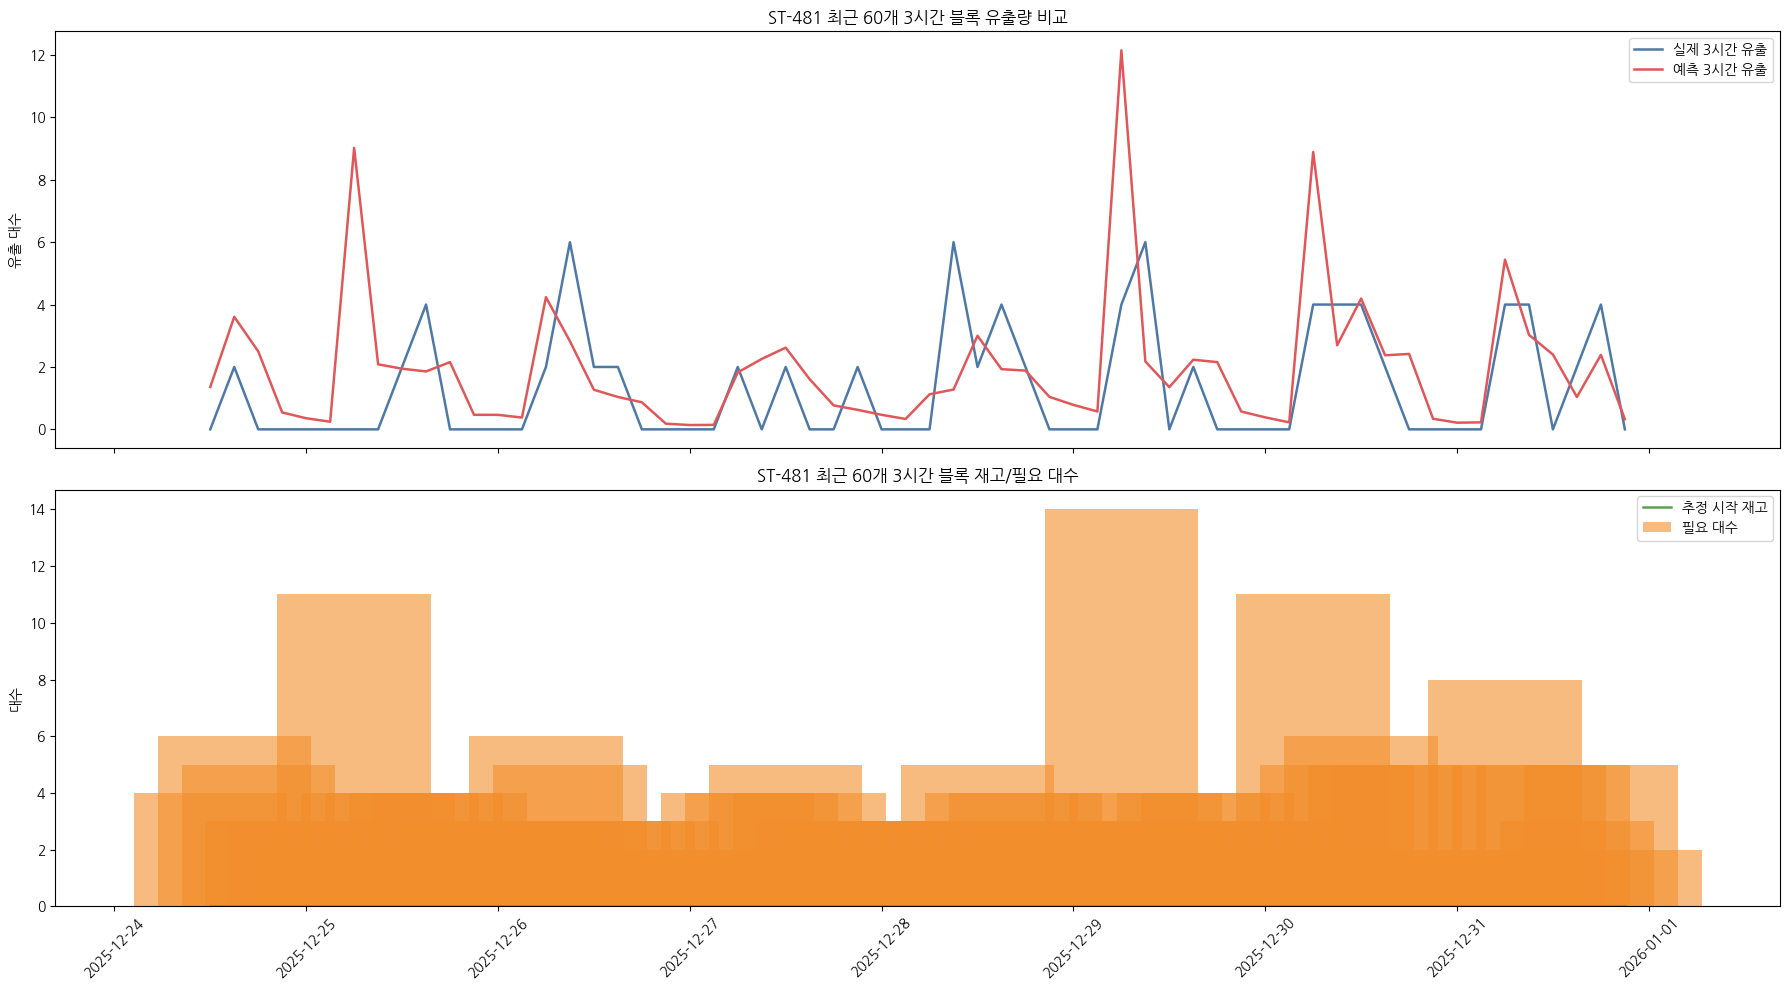

In [68]:
plot_station_id = need_bike_df_3h.groupby('대여소_ID')['needed_bikes_stock_based'].max().sort_values(ascending=False).index[0]

station_plot_df = need_bike_df_3h[need_bike_df_3h['대여소_ID'] == plot_station_id].copy()
station_plot_df = station_plot_df.sort_values('block_datetime').tail(60)
station_actual_df = test_2025_3h[test_2025_3h['대여소_ID'] == plot_station_id][['block_datetime', 'outflow_count', 'estimated_stock_start']].copy()
station_plot_df = station_plot_df.merge(station_actual_df, on='block_datetime', how='left', suffixes=('', '_actual'))

fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)

axes[0].plot(station_plot_df['block_datetime'], station_plot_df['outflow_count'], label='실제 3시간 유출', color='#4E79A7', linewidth=1.8)
axes[0].plot(station_plot_df['block_datetime'], station_plot_df['pred_outflow_3h'], label='예측 3시간 유출', color='#E15759', linewidth=1.8)
axes[0].set_title(f'{plot_station_id} 최근 60개 3시간 블록 유출량 비교')
axes[0].set_ylabel('유출 대수')
axes[0].legend()

axes[1].plot(station_plot_df['block_datetime'], station_plot_df['estimated_stock_start'], label='추정 시작 재고', color='#59A14F', linewidth=1.8)
axes[1].bar(station_plot_df['block_datetime'], station_plot_df['needed_bikes_stock_based'], label='필요 대수', color='#F28E2B', alpha=0.6)
axes[1].set_title(f'{plot_station_id} 최근 60개 3시간 블록 재고/필요 대수')
axes[1].set_ylabel('대수')
axes[1].legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [69]:
visual_summary_table = pd.concat([
    score_summary_table.assign(분석='1시간 모델'),
    score_summary_table_3h.assign(분석='3시간 모델')
], ignore_index=True)

visual_need_summary = need_bike_summary_3h.copy().sort_values('needed_bikes_max', ascending=False)
visual_need_summary['우선_관리_대상'] = np.where(visual_need_summary['needed_bikes_max'] > 0, '우선 확인', '모니터링')

display(visual_summary_table)
display(visual_need_summary)


,구간,MAE,RMSE,R2,분석
0,Train_2024,0.4595,0.8988,0.4867,1시간 모델
1,Valid_2024_FoldAvg,0.6057,1.1087,0.2946,1시간 모델
2,Test_2025,0.4949,0.9323,0.2569,1시간 모델
3,Train_2024_3h,0.9456,1.3783,0.7289,3시간 모델
4,Valid_2024_3h_FoldAvg,1.3437,2.0474,0.4613,3시간 모델
5,Test_2025_3h,1.1996,1.8280,0.2783,3시간 모델


,대여소_ID,pred_outflow_3h_mean,pred_outflow_3h_max,estimated_stock_mean,estimated_stock_min,needed_bikes_mean,needed_bikes_max,우선_관리_대상
2,ST-481,2.646948,24.933461,0.000000,0.0,4.781164,27.0,우선 확인
0,ST-464,0.732660,3.900060,323.750342,228.0,0.000000,0.0,모니터링
1,ST-479,1.315842,6.464541,2315.016781,1582.0,0.000000,0.0,모니터링
